# Naiwny klasyfikator bayesowski dla rozkładów dyskretnych
## Przykład: Bank Marketing

Celem projektu jest implementacja klasyfikatora bayesowskiego dla przypadku, w którym wszystkie cechy są **dyskretne albo jakościowe**. Dla obserwacji

$$
x=(x_1,x_2,\ldots,x_p)
$$

obliczamy prawdopodobieństwa a posteriori klas i wybieramy klasę o największej wartości tego prawdopodobieństwa.

W projekcie wykorzystujemy zbiór **Bank Marketing**. Klasyfikowana zmienna ma dwie wartości:

$$
K\in\{\text{no},\text{yes}\},
$$

gdzie `yes` oznacza zapisanie się klienta na lokatę terminową, a `no` brak zapisu.


## Podstawa matematyczna

Dla klasy $K=k$ i wektora cech $X=x$ korzystamy z twierdzenia Bayesa:

$$
P(K=k\mid X=x)=\frac{P(X=x\mid K=k)P(K=k)}{P(X=x)}.
$$

Ponieważ mianownik nie zależy od $k$, regułę decyzyjną można zapisać jako:

$$
\widehat{k}(x)=\arg\max_{k\in\mathcal{K}} P(K=k)P(X=x\mid K=k).
$$

W naiwnym klasyfikatorze bayesowskim zakładamy warunkową niezależność cech przy ustalonej klasie:

$$
P(X=x\mid K=k)=\prod_{j=1}^{p}P(X_j=x_j\mid K=k).
$$

Ostatecznie klasyfikator porównuje wielkości:

$$
s_k(x)=P(K=k)\prod_{j=1}^{p}P(X_j=x_j\mid K=k).
$$


## Estymacja prawdopodobieństw dyskretnych

Niech:

- $N_k$ - liczba obserwacji klasy $k$,
- $N_{k,j,v}$ - liczba obserwacji klasy $k$, dla których $X_j=v$,
- $|V_j|$ - liczba możliwych wartości cechy $X_j$.

Dla cech jakościowych estymujemy prawdopodobieństwa warunkowe przez częstości z wygładzaniem Laplace'a:

$$
\widehat{P}(X_j=v\mid K=k)=\frac{N_{k,j,v}+\alpha}{N_k+\alpha |V_j|}.
$$

W projekcie przyjmujemy $\alpha=1$. Dzięki temu żadna zaobserwowana kategoria nie otrzymuje prawdopodobieństwa równego zeru. Obliczenia wykonujemy w skali logarytmicznej:

$$
\log s_k(x)=\log P(K=k)+\sum_{j=1}^{p}\log P(X_j=x_j\mid K=k).
$$


## Wybrane cechy jakościowe

Pełny zbiór zawiera zarówno zmienne jakościowe, jak i liczbowe. Ponieważ temat dotyczy rozkładów dyskretnych, wykorzystujemy tylko zmienne jakościowe:

| Cecha | Znaczenie |
|---|---|
| `job` | typ pracy klienta |
| `marital` | stan cywilny |
| `education` | poziom wykształcenia |
| `default` | informacja o niespłacanym kredycie |
| `housing` | kredyt mieszkaniowy |
| `loan` | kredyt osobisty |
| `contact` | typ kontaktu |
| `month` | miesiąc kontaktu |
| `poutcome` | wynik poprzedniej kampanii |

Każda obserwacja należy więc do iloczynu kartezjańskiego skończonych zbiorów kategorii:

$$
X\in V_1\times V_2\times\ldots\times V_9.
$$


## Import bibliotek


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


## Pobranie i przygotowanie danych


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

with urlopen(url) as response:
    zip_data = BytesIO(response.read())

with ZipFile(zip_data) as z:
    with z.open("bank-full.csv") as file:
        df = pd.read_csv(file, sep=";")

print("Wymiary pełnego zbioru:", df.shape)
df.head()


Wymiary pełnego zbioru: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
cat_cols = [
    "job", "marital", "education", "default", "housing",
    "loan", "contact", "month", "poutcome"
]

X_df = df[cat_cols].astype(str)
y = df["y"].astype(str)
X = X_df.to_numpy()

print("Liczba obserwacji:", X.shape[0])
print("Liczba cech jakościowych:", X.shape[1])
print("\nRozkład klas:")
print(y.value_counts())
print("\nRozkład klas w procentach:")
print((100 * y.value_counts(normalize=True)).round(2))


Liczba obserwacji: 45211
Liczba cech jakościowych: 9

Rozkład klas:
y
no     39922
yes     5289
Name: count, dtype: int64

Rozkład klas w procentach:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


Rozkład klas jest nierównomierny. Wartość $P(K=\text{no})$ jest znacznie większa od $P(K=\text{yes})$, co będzie miało wpływ na klasyfikację. Z tego powodu oprócz zwykłej trafności będziemy analizować także miary uwzględniające obie klasy.


## Podział na próbę treningową i testową


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=y,
)

train_class_distribution = pd.Series(y_train).value_counts(normalize=True).sort_index()
class_prior_probabilities = train_class_distribution.to_dict()

print("Rozmiar próby treningowej:", X_train.shape)
print("Rozmiar próby testowej:", X_test.shape)
print("\nPrawdopodobieństwa a priori wyznaczone z próby treningowej:")
print(train_class_distribution.round(4))


Rozmiar próby treningowej: (36168, 9)
Rozmiar próby testowej: (9043, 9)

Prawdopodobieństwa a priori wyznaczone z próby treningowej:
no     0.883
yes    0.117
Name: proportion, dtype: float64


Wektor prawdopodobieństw a priori ma postać:

$$
\pi=(\pi_{no},\pi_{yes}), \qquad \pi_k=P(K=k), \qquad \sum_k \pi_k=1.
$$

W implementacji przekazujemy go jawnie do metody `fit`, zgodnie z wymaganiami projektu.


## Implementacja klasyfikatora


In [5]:
class NaiveBayesDiscrete:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y, priors=None):
        X = np.asarray(X).astype(str)
        y = np.asarray(y).astype(str)

        if X.ndim != 2:
            raise ValueError("X musi być macierzą dwuwymiarową.")
        if len(X) != len(y):
            raise ValueError("X i y muszą mieć tę samą liczbę obserwacji.")

        self.class_labels_, class_counts = np.unique(y, return_counts=True)
        self.class_counts_ = dict(zip(self.class_labels_, class_counts))
        self.n_features_ = X.shape[1]
        self.feature_values_ = [np.unique(X[:, j]).tolist() for j in range(self.n_features_)]
        self.class_priors_ = self._prepare_priors(priors, class_counts)

        self.likelihoods_ = {}
        self.unseen_probs_ = {}

        for klass in self.class_labels_:
            X_class = X[y == klass]
            n_k = len(X_class)
            self.likelihoods_[klass] = []
            self.unseen_probs_[klass] = []

            for j in range(self.n_features_):
                values = self.feature_values_[j]
                denominator = n_k + self.alpha * len(values)
                value_probs = {}

                for value in values:
                    count = np.sum(X_class[:, j] == value)
                    value_probs[value] = (count + self.alpha) / denominator

                self.likelihoods_[klass].append(value_probs)
                self.unseen_probs_[klass].append(self.alpha / denominator)

        return self

    def _prepare_priors(self, priors, class_counts):
        if priors is None:
            return class_counts / class_counts.sum()

        if isinstance(priors, dict):
            prior_values = np.array([priors[k] for k in self.class_labels_], dtype=float)
        else:
            prior_values = np.array(priors, dtype=float)
            if len(prior_values) != len(self.class_labels_):
                raise ValueError("Wektor prawdopodobieństw a priori ma niewłaściwą długość.")

        if np.any(prior_values < 0):
            raise ValueError("Prawdopodobieństwa a priori nie mogą być ujemne.")
        if prior_values.sum() <= 0:
            raise ValueError("Suma prawdopodobieństw a priori musi być dodatnia.")

        return prior_values / prior_values.sum()

    def predict_log_proba_unnormalized(self, X):
        X = np.asarray(X).astype(str)
        if X.ndim == 1:
            X = X.reshape(1, -1)

        log_scores = []
        for xi in X:
            row_scores = []
            for class_index, klass in enumerate(self.class_labels_):
                score = np.log(self.class_priors_[class_index])

                for j, value in enumerate(xi):
                    likelihood = self.likelihoods_[klass][j].get(
                        value,
                        self.unseen_probs_[klass][j]
                    )
                    score += np.log(likelihood)

                row_scores.append(score)
            log_scores.append(row_scores)

        return np.array(log_scores)

    def predict_proba(self, X):
        log_scores = self.predict_log_proba_unnormalized(X)
        shifted = log_scores - log_scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.class_labels_[np.argmax(probabilities, axis=1)]


## Uczenie modelu i prawdopodobieństwa a posteriori


In [6]:
model_empirical = NaiveBayesDiscrete(alpha=1.0)
model_empirical.fit(X_train, y_train, priors=class_prior_probabilities)

print("Klasy:", model_empirical.class_labels_)
print("\nPrawdopodobieństwa a priori użyte przez model:")
for klass, value in zip(model_empirical.class_labels_, model_empirical.class_priors_):
    print(f"P(K={klass}) = {value:.4f}")


Klasy: ['no' 'yes']

Prawdopodobieństwa a priori użyte przez model:
P(K=no) = 0.8830
P(K=yes) = 0.1170


In [7]:
y_pred = model_empirical.predict(X_test)
y_proba = model_empirical.predict_proba(X_test)

posterior_df = pd.DataFrame(
    y_proba,
    columns=[f"P(K={klass}|X=x)" for klass in model_empirical.class_labels_]
)
posterior_df["klasa_rzeczywista"] = y_test
posterior_df["klasa_prognozowana"] = y_pred
posterior_df.head()


,P(K=no|X=x),P(K=yes|X=x),klasa_rzeczywista,klasa_prognozowana
0,0.997776,0.002224,no,no
1,0.991403,0.008597,no,no
2,0.988889,0.011111,no,no
3,0.995619,0.004381,no,no
4,0.888608,0.111392,no,no


Powyższa tabela zawiera rozkład a posteriori dla kolejnych obserwacji testowych. Prognozowana klasa jest tą, dla której prawdopodobieństwo a posteriori jest największe.


## Ocena jakości klasyfikacji


In [8]:
accuracy_empirical = accuracy_score(y_test, y_pred)
balanced_empirical = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy_empirical:.4f}")
print(f"Balanced accuracy: {balanced_empirical:.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.8879
Balanced accuracy: 0.6294

Raport klasyfikacji:
              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7985
         yes       0.54      0.29      0.38      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.63      0.66      9043
weighted avg       0.87      0.89      0.87      9043



Dla problemu niezrównoważonego sama trafność może być myląca. Stosujemy więc również średnią czułość po klasach:

$$
\text{balanced accuracy}=\frac{1}{2}\left(\frac{TP}{TP+FN}+\frac{TN}{TN+FP}\right).
$$

Dla klasy `yes` szczególnie istotna jest czułość:

$$
\text{recall}_{yes}=\frac{TP}{TP+FN},
$$

ponieważ mierzy ona, jaka część rzeczywistych przypadków `yes` została wykryta przez klasyfikator.


## Porównanie z klasyfikatorem stałym


In [9]:
baseline_class = pd.Series(np.asarray(y_train)).mode().iloc[0]
baseline_pred = np.repeat(baseline_class, len(y_test))

print(f"Klasyfikator stały: zawsze przewiduje klasę '{baseline_class}'")
print(f"Accuracy: {accuracy_score(y_test, baseline_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, baseline_pred):.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, baseline_pred, zero_division=0))


Klasyfikator stały: zawsze przewiduje klasę 'no'
Accuracy: 0.8830
Balanced accuracy: 0.5000

Raport klasyfikacji:
              precision    recall  f1-score   support

          no       0.88      1.00      0.94      7985
         yes       0.00      0.00      0.00      1058

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.78      0.88      0.83      9043



In [10]:
def metrics_row(name, y_true, y_hat):
    report = classification_report(y_true, y_hat, output_dict=True, zero_division=0)
    return {
        "wariant": name,
        "accuracy": accuracy_score(y_true, y_hat),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_hat),
        "precision_yes": report["yes"]["precision"],
        "recall_yes": report["yes"]["recall"],
        "f1_yes": report["yes"]["f1-score"],
    }

comparison = pd.DataFrame([
    metrics_row("klasyfikator stały", y_test, baseline_pred),
    metrics_row("Bayes: prawdopodobieństwa a priori z próby treningowej", y_test, y_pred),
])

comparison.round(4)


,wariant,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes
0,klasyfikator stały,0.8830,0.5000,0.0000,0.0000,0.0000
1,Bayes: prawdopodobieństwa a priori z próby tre...,0.8879,0.6294,0.5383,0.2921,0.3787


Klasyfikator stały dobrze pokazuje, dlaczego trzeba uważać z interpretacją `accuracy`. Może on uzyskać wysoką trafność tylko dlatego, że jedna klasa występuje znacznie częściej. Naiwny klasyfikator bayesowski wykorzystuje natomiast rozkłady warunkowe cech i dlatego osiąga wyższą wartość `balanced accuracy` oraz dodatnią czułość dla klasy `yes`.


## Macierz pomyłek


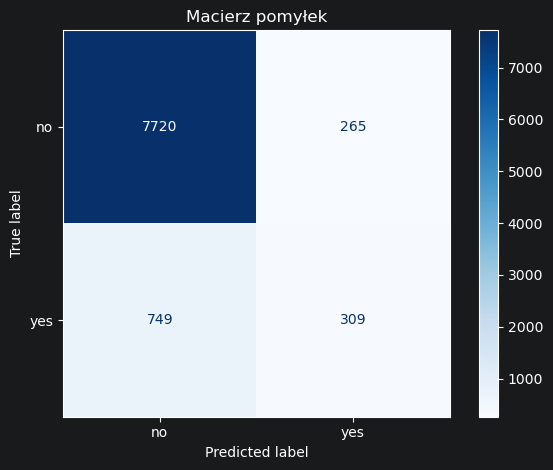

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=model_empirical.class_labels_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_empirical.class_labels_
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Macierz pomyłek")
plt.tight_layout()
plt.show()


Macierz pomyłek rozdziela błędy na dwa typy: fałszywe wskazania klasy `yes` oraz pominięte przypadki klasy `yes`. Dzięki temu widać, czy klasyfikator jest bardziej ostrożny, czy bardziej skłonny do wskazywania klasy mniejszościowej.


## Zależność cech jakościowych od klasy


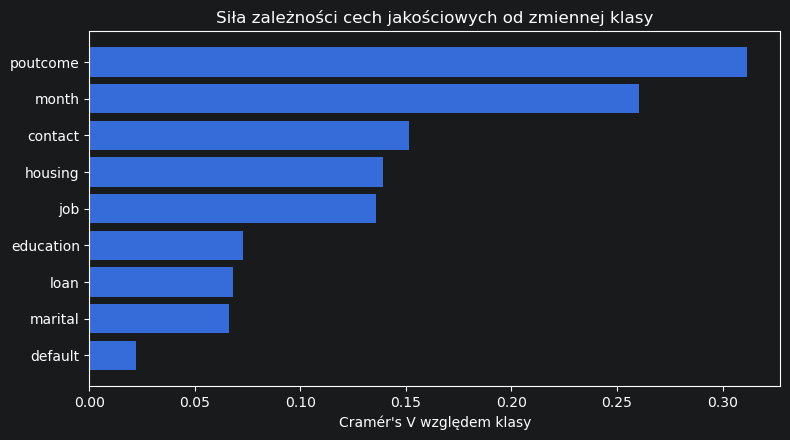

poutcome     0.312
month        0.260
contact      0.151
housing      0.139
job          0.136
education    0.073
loan         0.068
marital      0.066
default      0.022
dtype: float64

In [12]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, c = table.shape
    denominator = n * min(r - 1, c - 1)
    if denominator == 0:
        return 0.0
    return np.sqrt(chi2 / denominator)

cramer_target = pd.Series(
    {feature: cramers_v(df[feature], df["y"]) for feature in cat_cols}
).sort_values(ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(cramer_target.index, cramer_target.values)
plt.xlabel("Cramér's V względem klasy")
plt.title("Siła zależności cech jakościowych od zmiennej klasy")
plt.tight_layout()
plt.show()

cramer_target.sort_values(ascending=False).round(3)


Współczynnik Craméra $V$ jest miarą zależności między zmiennymi jakościowymi, opartą na statystyce $\chi^2$:

$$
V=\sqrt{\frac{\chi^2}{n\min(r-1,c-1)}}.
$$

Większa wartość oznacza silniejszą zależność empiryczną między daną cechą a klasą. Ta analiza nie jest częścią samej reguły Bayesa, ale pomaga zinterpretować, które cechy niosą najwięcej informacji o klasie.


## Wizualizacja rozkładów warunkowych wybranych cech


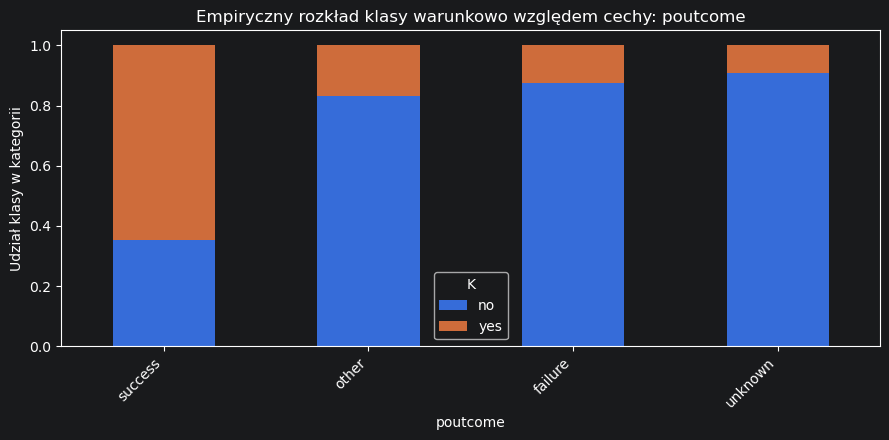

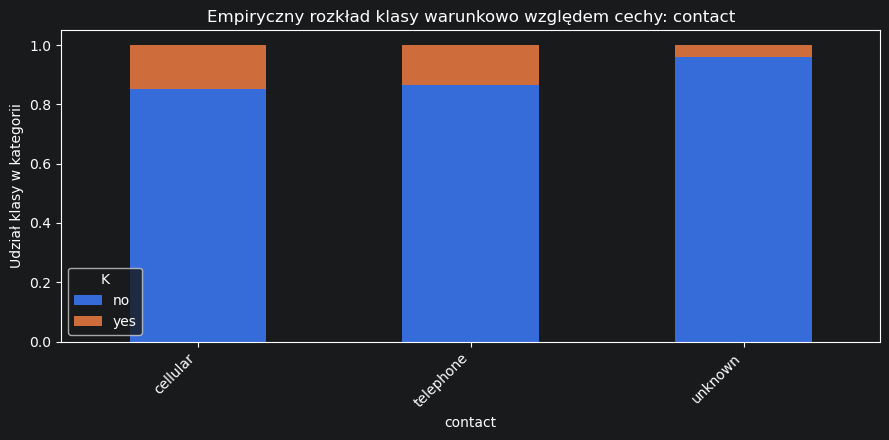

In [13]:
def plot_feature_vs_target(feature):
    table = pd.crosstab(df[feature], df["y"], normalize="index")
    table = table.sort_values("yes", ascending=False)

    table.plot(kind="bar", stacked=True, figsize=(9, 4.5))
    plt.title(f"Empiryczny rozkład klasy warunkowo względem cechy: {feature}")
    plt.ylabel("Udział klasy w kategorii")
    plt.xlabel(feature)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="K")
    plt.tight_layout()
    plt.show()

plot_feature_vs_target("poutcome")
plot_feature_vs_target("contact")


Wykresy pokazują empiryczne wartości zbliżone do $P(K=k\mid X_j=v)$. Jeżeli dla różnych kategorii tej samej cechy proporcje klas są bardzo różne, to dana cecha wpływa na iloczyn prawdopodobieństw w regule decyzyjnej.


## Wizualizacja prawdopodobieństw a posteriori


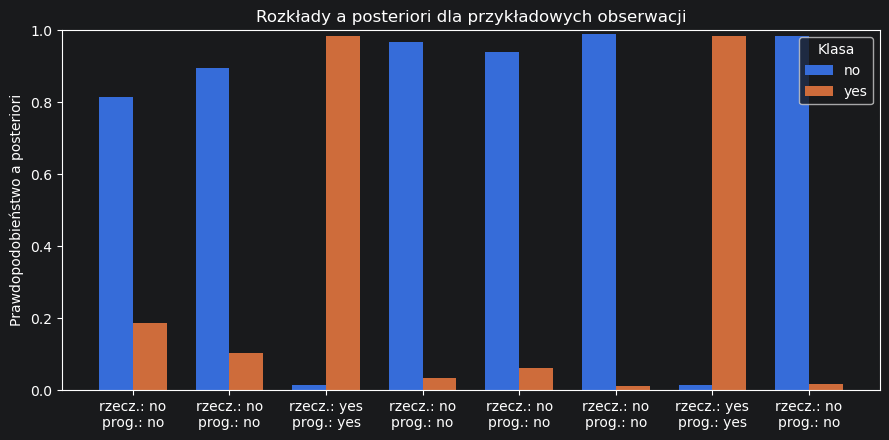

In [14]:
np.random.seed(42)
example_idx = np.random.choice(len(X_test), size=8, replace=False)
example_probs = model_empirical.predict_proba(X_test[example_idx])
example_true = y_test[example_idx]
example_pred = y_pred[example_idx]

plt.figure(figsize=(9, 4.5))
positions = np.arange(len(example_idx))
width = 0.35

plt.bar(positions - width / 2, example_probs[:, 0], width, label=model_empirical.class_labels_[0])
plt.bar(positions + width / 2, example_probs[:, 1], width, label=model_empirical.class_labels_[1])
plt.xticks(
    positions,
    [f"rzecz.: {t}\nprog.: {p}" for t, p in zip(example_true, example_pred)],
    rotation=0,
)
plt.ylim(0, 1)
plt.ylabel("Prawdopodobieństwo a posteriori")
plt.title("Rozkłady a posteriori dla przykładowych obserwacji")
plt.legend(title="Klasa")
plt.tight_layout()
plt.show()


Ta wizualizacja podkreśla, że klasyfikator nie zwraca wyłącznie etykiety. Najpierw wyznacza rozkład a posteriori na zbiorze klas, a dopiero potem stosuje regułę maksimum.


## Wpływ ręcznie zadanych prawdopodobieństw a priori


In [15]:
manual_prior_probabilities = {
    "no": 0.70,
    "yes": 0.30,
}

model_manual = NaiveBayesDiscrete(alpha=1.0)
model_manual.fit(X_train, y_train, priors=manual_prior_probabilities)

manual_pred = model_manual.predict(X_test)
manual_proba = model_manual.predict_proba(X_test)

comparison = pd.DataFrame([
    metrics_row("klasyfikator stały", y_test, baseline_pred),
    metrics_row("Bayes: prawdopodobieństwa a priori z próby treningowej", y_test, y_pred),
    metrics_row("Bayes: ręcznie zadane prawdopodobieństwa a priori", y_test, manual_pred),
])

comparison.round(4)


,wariant,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes
0,klasyfikator stały,0.8830,0.5000,0.0000,0.0000,0.0000
1,Bayes: prawdopodobieństwa a priori z próby tre...,0.8879,0.6294,0.5383,0.2921,0.3787
2,Bayes: ręcznie zadane prawdopodobieństwa a priori,0.8336,0.6811,0.3476,0.4820,0.4040


Zmiana prawdopodobieństw a priori zmienia składnik:

$$
\log\frac{P(K=\text{yes})}{P(K=\text{no})}.
$$

Jeżeli zwiększymy $P(K=\text{yes})$, to klasyfikator częściej będzie wskazywał klasę `yes`. Zwykle obniża to `accuracy`, ale może zwiększyć czułość dla klasy mniejszościowej i wartość `balanced accuracy`. Jest to dobry przykład wpływu założeń początkowych na regułę decyzyjną.


## Element dodatkowy: rozkład wkładów w logarytmicznym ilorazie szans


In [16]:
client = pd.DataFrame([{
    "job": "student",
    "marital": "single",
    "education": "tertiary",
    "default": "no",
    "housing": "no",
    "loan": "no",
    "contact": "cellular",
    "month": "mar",
    "poutcome": "success",
}])[cat_cols]

client_proba = model_empirical.predict_proba(client.to_numpy())[0]
client_prediction = model_empirical.predict(client.to_numpy())[0]

print("Przykładowa obserwacja:")
display(client)
print("\nPrawdopodobieństwa a posteriori:")
for klass, value in zip(model_empirical.class_labels_, client_proba):
    print(f"P(K={klass}|X=x) = {value:.4f}")
print("\nPrognozowana klasa:", client_prediction)


Przykładowa obserwacja:


,job,marital,education,default,housing,loan,contact,month,poutcome
0,student,single,tertiary,no,no,no,cellular,mar,success



Prawdopodobieństwa a posteriori:
P(K=no|X=x) = 0.0059
P(K=yes|X=x) = 0.9941

Prognozowana klasa: yes


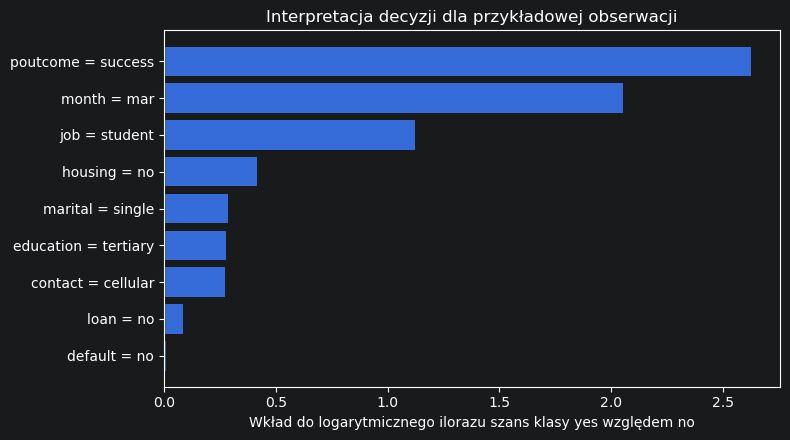

,cecha,wartość,wkład
8,poutcome,success,2.623017
7,month,mar,2.054497
0,job,student,1.120929
4,housing,no,0.416574
1,marital,single,0.287376
2,education,tertiary,0.277443
6,contact,cellular,0.273337
5,loan,no,0.087410
3,default,no,0.010028


In [17]:
def explain_log_odds(model, x, feature_names, positive_class="yes", negative_class="no"):
    x = np.asarray(x).astype(str).ravel()
    rows = []

    for j, value in enumerate(x):
        p_positive = model.likelihoods_[positive_class][j].get(
            value, model.unseen_probs_[positive_class][j]
        )
        p_negative = model.likelihoods_[negative_class][j].get(
            value, model.unseen_probs_[negative_class][j]
        )
        rows.append({
            "cecha": feature_names[j],
            "wartość": value,
            "wkład": np.log(p_positive) - np.log(p_negative),
        })

    result = pd.DataFrame(rows)
    return result.sort_values("wkład")

log_odds_parts = explain_log_odds(model_empirical, client.to_numpy()[0], cat_cols)

plt.figure(figsize=(8, 4.5))
plt.barh(log_odds_parts["cecha"] + " = " + log_odds_parts["wartość"], log_odds_parts["wkład"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Wkład do logarytmicznego ilorazu szans klasy yes względem no")
plt.title("Interpretacja decyzji dla przykładowej obserwacji")
plt.tight_layout()
plt.show()

log_odds_parts.sort_values("wkład", ascending=False)


Dla dwóch klas można analizować logarytmiczny iloraz szans:

$$
\log\frac{s_{yes}(x)}{s_{no}(x)}=
\log\frac{P(K=\text{yes})}{P(K=\text{no})}
+
\sum_{j=1}^{p}\log\frac{P(X_j=x_j\mid K=\text{yes})}{P(X_j=x_j\mid K=\text{no})}.
$$

Dodatnie składniki przesuwają decyzję w stronę klasy `yes`, a ujemne w stronę klasy `no`. Jest to matematyczna interpretacja pojedynczej decyzji klasyfikatora.


# Wnioski końcowe

1. Wygładzanie Laplace'a zabezpiecza model przed zerowymi prawdopodobieństwami dla nierównych kategorii.

2. Nierównomierny rozkład klas powoduje, że sama trafność nie jest wystarczającą oceną. Bardziej informacyjne są `balanced accuracy` oraz czułość dla klasy `yes`.

3. Ręczna zmiana prawdopodobieństw a priori pokazuje, że składnik $P(K=k)$ nie jest tylko formalnością - realnie przesuwa regułę decyzyjną.

4. Naiwny klasyfikator bayesowski jest prosty obliczeniowo, ale ma jasną interpretację matematyczną: decyzja wynika z porównania iloczynów prawdopodobieństw warunkowych i prawdopodobieństw a priori.
